In [2]:
import os
import pandas as pd

In [ ]:
df_ros = pd.read_csv('/home/jupyter-yehlin/Pairformer/Benorr/lucs_df.csv')
df_ros_pred_result = pd.read_csv('/home/jupyter-yehlin/ESM3_SaProt_dG/model_predictions_benorr.csv')
# df_af2_pred_result = pd.read_csv('/home/jupyter-yehlin/Pairformer/Benorr/af2_predictions.csv')

/tmp/ipykernel_3424144/1030742604.py:1: DtypeWarning: Columns (55) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ros = pd.read_csv('/home/jupyter-yehlin/Pairformer/Benorr/lucs_df.csv')


In [29]:
for key in df_ros.keys():
    print(key)

design_id
af2_design_id
lucs_design_id
sequence
bb_remodeled_residues
ave_plddt_af2_model1
ave_lhl0_plddt_af2_model1
ave_lhl1_plddt_af2_model1
ave_bb_rem_plddt_af2_model1
ave_non_bb_rem_plddt_af2_model1
plddts_af2_model1
lhl0_plddts_af2_model1
lhl1_plddts_af2_model1
bb_rem_plddts_af2_model1
non_bb_rem_plddts_af2_model1
ave_plddt_af2_model2
ave_lhl0_plddt_af2_model2
ave_lhl1_plddt_af2_model2
ave_bb_rem_plddt_af2_model2
ave_non_bb_rem_plddt_af2_model2
plddts_af2_model2
lhl0_plddts_af2_model2
lhl1_plddts_af2_model2
bb_rem_plddts_af2_model2
non_bb_rem_plddts_af2_model2
ave_plddt_af2_model3
ave_lhl0_plddt_af2_model3
ave_lhl1_plddt_af2_model3
ave_bb_rem_plddt_af2_model3
ave_non_bb_rem_plddt_af2_model3
plddts_af2_model3
lhl0_plddts_af2_model3
lhl1_plddts_af2_model3
bb_rem_plddts_af2_model3
non_bb_rem_plddts_af2_model3
ave_plddt_af2_model4
ave_lhl0_plddt_af2_model4
ave_lhl1_plddt_af2_model4
ave_bb_rem_plddt_af2_model4
ave_non_bb_rem_plddt_af2_model4
plddts_af2_model4
lhl0_plddts_af2_model4
lhl

In [4]:
print(len([file for file in  os.listdir('/home/jupyter-yehlin/Pairformer/Benorr/round3_ordered_designs_af2_preds')  if file.endswith('.pdb')]))
print(len(df_ros))

50030
10000


In [5]:
# [file for file in  os.listdir('/home/jupyter-yehlin/Pairformer/Benorr/round3_ordered_designs_af2_preds')  if '_rank_1' in file and file.endswith('.pdb')]

In [8]:
df_ros['stable_by_ec50'].value_counts()

stable_by_ec50
stable            5996
uncertain_95ci    3252
uncertain          499
unstable           184
Name: count, dtype: int64

In [9]:
df_ros_merged = df_ros[['design_id', 'af2_design_id', 'stable_by_ec50', 'ec50_c', 'ec50_t']].merge(df_ros_pred_result, left_on='design_id', right_on='PDB', how='inner')

In [15]:
df_ros_merged_stable_unstable = df_ros_merged

In [23]:
df_ros_merged_stable_unstable['stability'] = 0
df_ros_merged_stable_unstable.loc[df_ros_merged_stable_unstable['stable_by_ec50'].isin(['uncertain_95ci','uncertain']), 'stability'] = 2
df_ros_merged_stable_unstable.loc[df_ros_merged_stable_unstable['stable_by_ec50'] == 'stable', 'stability'] = 1

Spearman correlation: 0.049
P-value: 8.103e-07


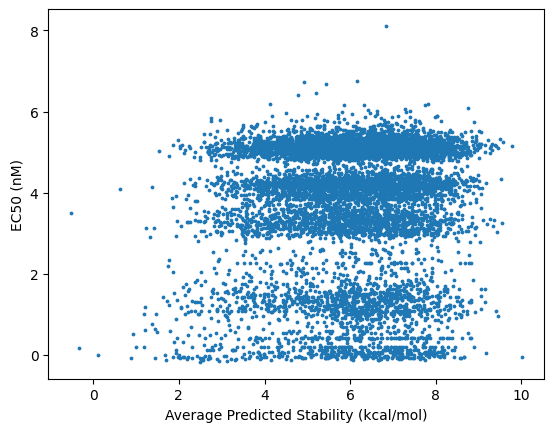

In [24]:
from scipy import stats
import matplotlib.pyplot as plt
df_clean = df_ros_merged_stable_unstable.dropna(subset=['Model1', 'ec50_c'])
correlation, p_value = stats.spearmanr(df_clean['Model1'], df_clean['ec50_c'])
print(f"Spearman correlation: {correlation:.3f}")
print(f"P-value: {p_value:.3e}")

plt.scatter(df_clean['Average'], df_clean['ec50_c'],s=3)
plt.xlabel('Average Predicted Stability (kcal/mol)')
plt.ylabel('EC50 (nM)')
plt.show()

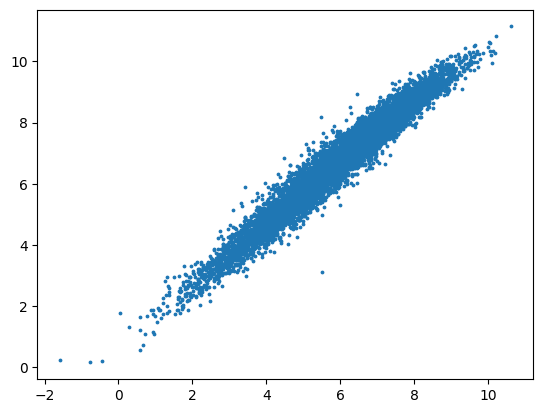

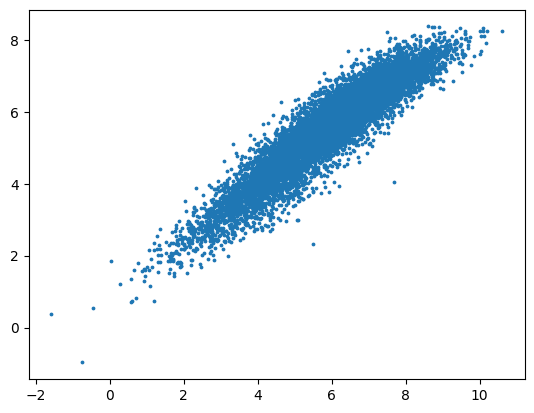

In [25]:
plt.scatter(df_ros_merged_stable_unstable['Model1'], df_ros_merged_stable_unstable['Model2'],s=3)
plt.show()

plt.scatter(df_ros_merged_stable_unstable['Model1'], df_ros_merged_stable_unstable['Model3'],s=3)
plt.show()

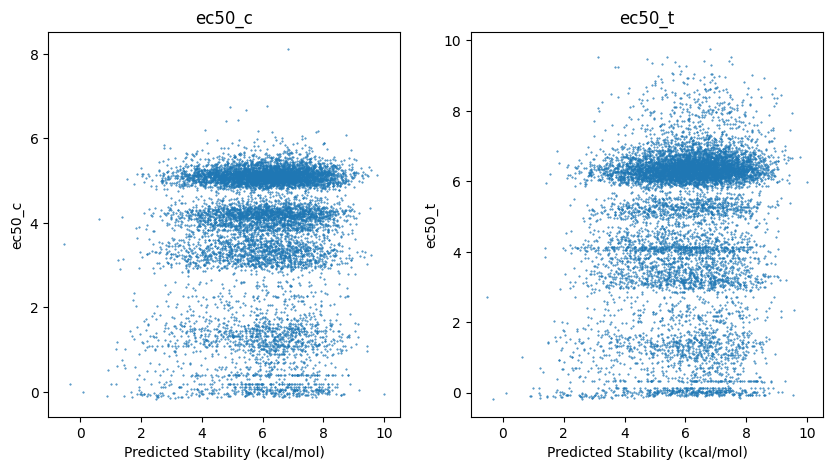

In [34]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(df_ros_merged_stable_unstable['Average'], df_ros_merged_stable_unstable['ec50_c'],s=0.2)
axs[0].set_title('ec50_c')
axs[0].set_xlabel('Predicted Stability (kcal/mol)')
axs[0].set_ylabel('ec50_c')
axs[1].scatter(df_ros_merged_stable_unstable['Average'], df_ros_merged_stable_unstable['ec50_t'],s=0.2)
axs[1].set_title('ec50_t')
axs[1].set_xlabel('Predicted Stability (kcal/mol)')
axs[1].set_ylabel('ec50_t')
plt.show()

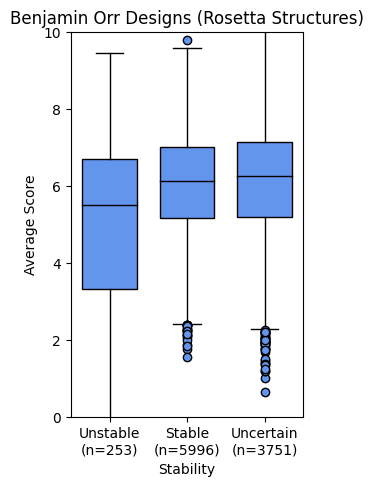

In [26]:
import matplotlib.pyplot as plt

# Get counts for each group
n_unstable = len(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==0])
n_stable = len(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==1])
n_uncertain = len(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==2])

plt.figure(figsize=(3,5))
plt.boxplot([df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==0]['Average'], 
            df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==1]['Average'],
            df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==2]['Average']], 
            labels=[f'Unstable\n(n={n_unstable})', f'Stable\n(n={n_stable})', f'Uncertain\n(n={n_uncertain})'], 
            patch_artist=True,
            boxprops=dict(facecolor='cornflowerblue', linestyle='solid'),
            medianprops=dict(color='black'),
            flierprops=dict(markerfacecolor='cornflowerblue'),
            positions=[0,1,2],
            widths=0.7)

plt.xlabel('Stability')
plt.ylabel('Average Score')
plt.title('Benjamin Orr Designs (Rosetta Structures)')
plt.ylim(0,10)
plt.show()

/home/jupyter-yehlin/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-yehlin/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-yehlin/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


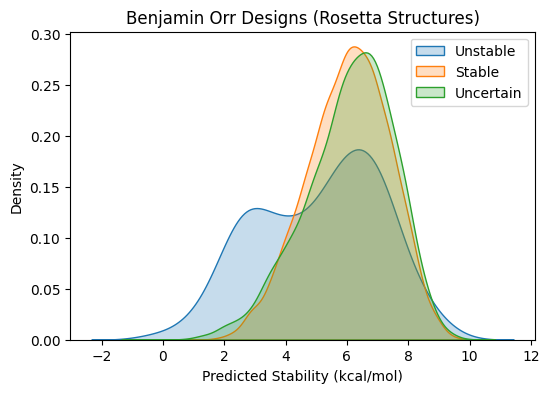

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.kdeplot(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==0]['Average'], label='Unstable', fill=True)
sns.kdeplot(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==1]['Average'], label='Stable', fill=True)
sns.kdeplot(df_ros_merged_stable_unstable[df_ros_merged_stable_unstable['stability']==2]['Average'], label='Uncertain', fill=True)
plt.xlabel('Predicted Stability (kcal/mol)')
plt.ylabel('Density')
plt.title('Benjamin Orr Designs (Rosetta Structures)')
plt.legend()
plt.show()